# Transformer Encoder Baseline for WLASL Sign Recognition Using MediaPipe Landmarks

This notebook creates the **next model after Random Forest, HMM, LSTM, and ST-GCN**.

You have already tested:

| Model | Stage | What it tests |
|---|---|---|
| Random Forest | Traditional ML baseline | Can simple landmark summaries classify signs? |
| HMM | Traditional temporal baseline | Can simple state transitions model sign motion? |
| LSTM | Deep temporal baseline | Can deep sequence memory learn sign movement? |
| ST-GCN | Graph temporal baseline | Can graph-based joint relationships improve recognition? |
| **Transformer Encoder** | Attention-based temporal baseline | Can attention learn important frames and movements? |

## Why Transformer is next

Sign language videos contain important information across time.  
Some frames matter more than others.

A Transformer model uses **self-attention** to learn:

- which frames are important
- which parts of the sequence relate to each other
- how motion patterns across time support sign recognition

## Important

This notebook is still a **recognition baseline**, not the final full bidirectional KSL healthcare system.

It helps support the project argument that the final architecture should include:

```text
ST-GCN + Transformer + language model + diffusion/avatar generation
```

## What this notebook does

1. Loads WLASL through FiftyOne.
2. Selects the same fixed classes used in previous models.
3. Extracts MediaPipe pose, hand, and face landmark sequences.
4. Pads/truncates every video to the same length.
5. Scales features.
6. Trains a PyTorch Transformer Encoder classifier.
7. Evaluates accuracy, precision, recall, F1-score, confusion matrix, and classification report.
8. Saves the model, scaler, label encoder, and metadata.

## Why we use landmarks instead of raw video frames

A full raw-video transformer is heavier and requires more GPU/data.

This notebook uses a lighter approach:

```text
video → MediaPipe landmarks → Transformer Encoder
```

This is suitable for your current Docker/CPU setup and still gives strong evidence for model comparison.

## 1. Install PyTorch if needed

Skip this if PyTorch is already installed in Docker.

If missing, uncomment and run this cell.

In [1]:
# Uncomment only if torch is missing
# import sys
# !{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

## 2. Import libraries

The notebook uses:

- `FiftyOne` to load WLASL
- `MediaPipe` to extract landmarks
- `PyTorch` to train the Transformer
- `scikit-learn` to calculate evaluation metrics

In [2]:
import os
import sys
import json
import math
import random
import logging
from pathlib import Path
from datetime import datetime
from collections import Counter

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

import fiftyone as fo
import fiftyone.utils.huggingface as fouh
import mediapipe as mp

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("FiftyOne database URI:", os.environ.get("FIFTYONE_DATABASE_URI"))
print("MediaPipe version:", getattr(mp, "__version__", "unknown"))
print("MediaPipe has solutions:", hasattr(mp, "solutions"))
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.11.15 (main, May 19 2026, 23:49:45) [GCC 14.2.0]
Python executable: /usr/local/bin/python
FiftyOne database URI: mongodb://mongo:27017
MediaPipe version: 0.10.21
MediaPipe has solutions: True
Torch version: 2.12.0+cpu
CUDA available: False


## 3. Configure folders and logging

All outputs are saved to:

```text
/workspace/dataset/ksl_project_data/
```

This includes:

- logs
- cached extracted features
- trained models
- metadata

In [3]:
PROJECT_DIR = Path("/workspace/dataset/ksl_project_data").resolve()

# Fallback for local non-Docker execution
if not Path("/workspace/dataset").exists():
    PROJECT_DIR = Path("ksl_project_data").resolve()

LOG_DIR = PROJECT_DIR / "logs"
FEATURE_DIR = PROJECT_DIR / "features"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [PROJECT_DIR, LOG_DIR, FEATURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

log_file = LOG_DIR / f"transformer_wlasl_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)

logger = logging.getLogger(__name__)
logger.info("Transformer Encoder notebook started")
logger.info(f"Project directory: {PROJECT_DIR}")

print("Project directory:", PROJECT_DIR)
print("Log file:", log_file)

2026-06-05 12:09:21,029 | INFO | Transformer Encoder notebook started
2026-06-05 12:09:21,031 | INFO | Project directory: /workspace/dataset/ksl_project_data
Project directory: /workspace/dataset/ksl_project_data
Log file: /workspace/dataset/ksl_project_data/logs/transformer_wlasl_20260605_120921.log


## 4. Set random seed

This improves reproducibility.

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## 5. Load WLASL dataset

This loads the same dataset used by the previous notebooks.

If WLASL is already in your FiftyOne database, it loads the local copy.  
If not, it loads the dataset from the Hugging Face/FiftyOne hub.

In [5]:
DATASET_NAME = "Voxel51/WLASL"

if DATASET_NAME in fo.list_datasets():
    logger.info("Loading existing local WLASL dataset")
    dataset = fo.load_dataset(DATASET_NAME)
else:
    logger.info("Loading WLASL from Hugging Face/FiftyOne hub")
    dataset = fouh.load_from_hub(DATASET_NAME, persistent=True)

dataset.persistent = True

logger.info(f"Dataset loaded: {dataset.name}")
logger.info(f"Total samples: {len(dataset)}")

print("Dataset:", dataset.name)
print("Total samples:", len(dataset))
print("Field schema:", dataset.get_field_schema())

2026-06-05 12:10:05,207 | INFO | Loading existing local WLASL dataset
2026-06-05 12:10:05,282 | INFO | Dataset loaded: Voxel51/WLASL
2026-06-05 12:10:05,285 | INFO | Total samples: 11980
Dataset: Voxel51/WLASL
Total samples: 11980
Field schema: OrderedDict([('id', <fiftyone.core.fields.ObjectIdField object at 0x7f8494d6d1d0>), ('filepath', <fiftyone.core.fields.StringField object at 0x7f849473e950>), ('tags', <fiftyone.core.fields.ListField object at 0x7f8506fd9b10>), ('metadata', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f84949e2750>), ('created_at', <fiftyone.core.fields.DateTimeField object at 0x7f8494cf4750>), ('last_modified_at', <fiftyone.core.fields.DateTimeField object at 0x7f8494f00690>), ('bounding_box', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f8494b822d0>), ('gloss', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f84946ec490>)])


## 6. Label extraction helper

Different dataset versions may store the sign label under different fields.

This helper checks common fields and returns the sign label for each video.

In [6]:
def get_label_from_sample(sample):
    candidate_fields = ["ground_truth", "label", "labels", "classification", "word", "gloss"]

    for field in candidate_fields:
        if field in sample:
            value = sample[field]

            if value is None:
                continue

            if hasattr(value, "label"):
                return value.label

            if isinstance(value, str):
                return value

    for field in sample.field_names:
        value = sample[field]

        if hasattr(value, "label"):
            return value.label

        if field.lower() in ["word", "gloss", "label"] and isinstance(value, str):
            return value

    return None


labels = []
missing_labels = 0

for sample in dataset:
    label = get_label_from_sample(sample)

    if label is None:
        missing_labels += 1
    else:
        labels.append(label)

label_counts = Counter(labels)

print("Samples with labels:", len(labels))
print("Samples missing labels:", missing_labels)
print("Unique labels:", len(label_counts))
print("Top 20 labels:")

for label, count in label_counts.most_common(20):
    print(label, count)

Samples with labels: 11980
Samples missing labels: 0
Unique labels: 2000
Top 20 labels:
before 16
cool 16
thin 16
drink 15
go 15
computer 14
cousin 14
help 14
who 14
accident 13
bed 13
bowling 13
candy 13
short 13
tall 13
thanksgiving 13
trade 13
basketball 12
call 12
change 12


## 7. Select fixed classes for fair comparison

We use the same classes from previous experiments:

```text
before, computer, cool, cousin, drink
```

These are benchmark signs from WLASL.  
They are not final healthcare phrases.

They help us compare models fairly because each model is tested on the same task.

In [7]:
FIXED_CLASSES = ["before", "computer", "cool", "cousin", "drink"]
MAX_SAMPLES_PER_CLASS = 40

selected_labels_set = set(FIXED_CLASSES)
selected_samples = []
per_class_counter = Counter()

for sample in dataset:
    label = get_label_from_sample(sample)

    if label in selected_labels_set and per_class_counter[label] < MAX_SAMPLES_PER_CLASS:
        if sample.filepath and Path(sample.filepath).exists():
            selected_samples.append(sample)
            per_class_counter[label] += 1

logger.info(f"Selected classes: {FIXED_CLASSES}")
logger.info(f"Selected usable video samples: {len(selected_samples)}")

print("Selected classes:", FIXED_CLASSES)
print("Selected usable videos:", len(selected_samples))
print("Per-class counts:", per_class_counter)

2026-06-05 12:11:28,479 | INFO | Selected classes: ['before', 'computer', 'cool', 'cousin', 'drink']
2026-06-05 12:11:28,481 | INFO | Selected usable video samples: 67
Selected classes: ['before', 'computer', 'cool', 'cousin', 'drink']
Selected usable videos: 67
Per-class counts: Counter({'before': 15, 'computer': 14, 'cool': 13, 'cousin': 13, 'drink': 12})


## 8. MediaPipe Holistic setup

This notebook uses:

- pose landmarks
- left hand landmarks
- right hand landmarks
- face landmarks

Each frame becomes one long feature vector.

The Transformer then learns attention across the frame sequence.

In [8]:
try:
    mp_holistic = mp.solutions.holistic
    print("Using mp.solutions.holistic")
except AttributeError:
    from mediapipe.python.solutions import holistic as mp_holistic
    print("Using mediapipe.python.solutions.holistic fallback")

POSE_LANDMARKS = 33
HAND_LANDMARKS = 21
FACE_LANDMARKS = 468
FEATURES_PER_LANDMARK = 3

FRAME_FEATURE_SIZE = (
    POSE_LANDMARKS * FEATURES_PER_LANDMARK
    + HAND_LANDMARKS * FEATURES_PER_LANDMARK
    + HAND_LANDMARKS * FEATURES_PER_LANDMARK
    + FACE_LANDMARKS * FEATURES_PER_LANDMARK
)

print("Frame feature size:", FRAME_FEATURE_SIZE)

Using mp.solutions.holistic
Frame feature size: 1629


## 9. Landmark extraction functions

This section converts each sign video into a sequence.

For every sampled frame:

1. Read frame from video.
2. Convert BGR to RGB.
3. Run MediaPipe Holistic.
4. Extract pose, left hand, right hand, and face landmarks.
5. Flatten them into one vector.

The output for one video is:

```text
time_steps × frame_feature_size
```

In [9]:
def flatten_landmarks(landmarks, expected_count):
    if landmarks is None:
        return np.zeros(expected_count * FEATURES_PER_LANDMARK, dtype=np.float32)

    values = []

    for lm in landmarks.landmark[:expected_count]:
        values.extend([lm.x, lm.y, lm.z])

    expected_length = expected_count * FEATURES_PER_LANDMARK

    if len(values) < expected_length:
        values.extend([0.0] * (expected_length - len(values)))

    return np.array(values[:expected_length], dtype=np.float32)


def extract_video_landmark_sequence(video_path, max_frames=60, frame_stride=2):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    sequence = []
    frame_index = 0

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        refine_face_landmarks=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as holistic:

        while cap.isOpened() and len(sequence) < max_frames:
            success, frame = cap.read()

            if not success:
                break

            if frame_index % frame_stride != 0:
                frame_index += 1
                continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)

            pose = flatten_landmarks(results.pose_landmarks, POSE_LANDMARKS)
            left_hand = flatten_landmarks(results.left_hand_landmarks, HAND_LANDMARKS)
            right_hand = flatten_landmarks(results.right_hand_landmarks, HAND_LANDMARKS)
            face = flatten_landmarks(results.face_landmarks, FACE_LANDMARKS)

            frame_features = np.concatenate([pose, left_hand, right_hand, face])
            sequence.append(frame_features)

            frame_index += 1

    cap.release()

    if len(sequence) == 0:
        return None

    return np.vstack(sequence).astype(np.float32)


def pad_or_truncate_sequence(sequence, target_length=60):
    feature_size = sequence.shape[1]

    if len(sequence) >= target_length:
        return sequence[:target_length]

    padded = np.zeros((target_length, feature_size), dtype=np.float32)
    padded[:len(sequence)] = sequence

    return padded

## 10. Extract or load cached Transformer sequences

MediaPipe extraction is slow, so this cell caches extracted sequences.

If the cache exists, it loads it immediately.

If not, it processes the videos and saves the cache.

In [10]:
TRANSFORMER_SEQUENCE_CACHE = FEATURE_DIR / "wlasl_transformer_sequences_fixed_classes.joblib"

MAX_FRAMES = 60
FRAME_STRIDE = 2

if TRANSFORMER_SEQUENCE_CACHE.exists():
    logger.info(f"Loading cached Transformer sequences from {TRANSFORMER_SEQUENCE_CACHE}")
    cached = joblib.load(TRANSFORMER_SEQUENCE_CACHE)
    X_sequences = cached["X_sequences"]
    y_labels = cached["y_labels"]
else:
    logger.info("Extracting Transformer landmark sequences from videos")

    X_list = []
    y_list = []
    failed = []

    for index, sample in enumerate(selected_samples, start=1):
        label = get_label_from_sample(sample)

        try:
            sequence = extract_video_landmark_sequence(
                sample.filepath,
                max_frames=MAX_FRAMES,
                frame_stride=FRAME_STRIDE,
            )

            if sequence is None:
                failed.append((sample.filepath, "No landmarks extracted"))
                continue

            fixed_sequence = pad_or_truncate_sequence(sequence, target_length=MAX_FRAMES)

            X_list.append(fixed_sequence)
            y_list.append(label)

            if index % 10 == 0:
                logger.info(f"Processed {index}/{len(selected_samples)} videos")

        except Exception as exc:
            failed.append((sample.filepath, str(exc)))
            logger.warning(f"Failed sample {sample.filepath}: {exc}")

    X_sequences = np.stack(X_list).astype(np.float32)
    y_labels = np.array(y_list)

    joblib.dump(
        {
            "X_sequences": X_sequences,
            "y_labels": y_labels,
            "fixed_classes": FIXED_CLASSES,
            "max_frames": MAX_FRAMES,
            "frame_stride": FRAME_STRIDE,
        },
        TRANSFORMER_SEQUENCE_CACHE,
    )

    logger.info(f"Saved Transformer sequence cache: {TRANSFORMER_SEQUENCE_CACHE}")
    logger.info(f"Failed videos: {len(failed)}")

print("X_sequences shape:", X_sequences.shape)
print("y_labels shape:", y_labels.shape)
print("Classes:", sorted(set(y_labels)))
print("Expected shape format: samples × time × features")

2026-06-05 12:12:52,945 | INFO | Extracting Transformer landmark sequences from videos


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780661574.197706    6289 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661575.826826    6287 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661575.840325    6294 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661576.061452    6291 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
W0000 00:00:1780661576.091230    6290 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:

2026-06-05 12:13:47,099 | INFO | Processed 10/67 videos


W0000 00:00:1780661627.201631    6465 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661627.220601    6465 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661627.223980    6466 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661627.224639    6470 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661627.225395    6464 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661627.231064    6466 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 12:14:44,078 | INFO | Processed 20/67 videos


...

2026-06-05 12:16:25,997 | INFO | Processed 50/67 videos


W0000 00:00:1780661786.124378    7120 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661786.152023    7120 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661786.157302    7120 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661786.158174    7122 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661786.158708    7124 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661786.168877    7122 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 12:16:52,650 | INFO | Processed 60/67 videos


W0000 00:00:1780661812.786288    7282 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661812.848352    7282 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661812.852098    7287 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661812.852809    7282 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661812.853037    7284 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780661812.873915    7284 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 12:17:10,573 | INFO | Saved Transformer sequence cache: /workspace/dataset/ksl_project_data/features/wlasl_transformer_sequences_fixed_classes.joblib
2026-06-05 12:17:10,575 | INFO | Failed videos: 0
X_sequences shape: (67, 60, 1629)
y_labels shape: (67,)
Classes: ['before', 'computer', 'cool', 'cousin', 'drink']
Expected shape format: samples × time × features


## 11. Encode labels and split train/test data

Labels such as `computer` and `drink` are converted to numeric class IDs.

We split by video sample to prevent leakage.

In [11]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

X_train, X_test, y_train, y_test = train_test_split(
    X_sequences,
    y_encoded,
    test_size=0.25,
    random_state=SEED,
    stratify=y_encoded,
)

print("Training videos:", X_train.shape[0])
print("Testing videos:", X_test.shape[0])
print("Sequence length:", X_train.shape[1])
print("Feature size:", X_train.shape[2])

print("Classes:")
for idx, label in enumerate(label_encoder.classes_):
    print(idx, "=>", label)

Training videos: 50
Testing videos: 17
Sequence length: 60
Feature size: 1629
Classes:
0 => before
1 => computer
2 => cool
3 => cousin
4 => drink


## 12. Scale features

Transformer training is more stable when features are normalized.

The scaler is fit only on training data, then applied to both train and test.

In [12]:
scaler = StandardScaler()

N_train, T, F = X_train.shape
N_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, F)
X_test_2d = X_test.reshape(-1, F)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(N_train, T, F).astype(np.float32)
X_test_scaled = scaler.transform(X_test_2d).reshape(N_test, T, F).astype(np.float32)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (50, 60, 1629)
Scaled test shape: (17, 60, 1629)


## 13. PyTorch Dataset and DataLoader

This prepares batches for training.

Each input has shape:

```text
batch_size × time_steps × feature_size
```

In [13]:
class SignSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 8

train_dataset = SignSequenceDataset(X_train_scaled, y_train)
test_dataset = SignSequenceDataset(X_test_scaled, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 7
Test batches: 3


## 14. Positional encoding

Transformers do not automatically know frame order.

Positional encoding adds sequence position information so the model can understand:

```text
frame 1 comes before frame 2
frame 2 comes before frame 3
...
```

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: batch × time × d_model
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

## 15. Define Transformer Encoder classifier

The model flow is:

```text
landmark sequence
→ input projection
→ positional encoding
→ transformer encoder layers
→ average pooling over time
→ classifier
→ sign prediction
```

Why input projection?

The raw landmark feature vector is large.  
The projection converts it to a smaller embedding size such as 128.

In [16]:
class TransformerSignClassifier(nn.Module):
    def __init__(
        self,
        input_size,
        num_classes,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.3,
        max_len=60,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x):
        # x shape: batch × time × features

        x = self.input_projection(x)
        x = self.positional_encoding(x)

        encoded = self.transformer_encoder(x)

        # Mean pooling over time
        pooled = encoded.mean(dim=1)

        logits = self.classifier(pooled)

        return logits


INPUT_SIZE = X_train_scaled.shape[2]
NUM_CLASSES = len(label_encoder.classes_)

D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 256
DROPOUT = 0.3

model = TransformerSignClassifier(
    input_size=INPUT_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=MAX_FRAMES,
).to(device)

print(model)

TransformerSignClassifier(
  (input_projection): Linear(in_features=1629, out_features=128, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): D

## 16. Train the Transformer model

Because the dataset subset is small, the model can overfit.

Watch these values:

- training accuracy
- test accuracy

If training improves but test does not, the model is memorizing the small training set.

In [17]:
EPOCHS = 30
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}


def run_epoch(loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    avg_accuracy = accuracy_score(all_targets, all_preds)

    return avg_loss, avg_accuracy


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, optimizer=optimizer)
    test_loss, test_acc = run_epoch(test_loader, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

Epoch 01/30 | Train Loss: 1.7214 | Train Acc: 0.2400 | Test Loss: 1.5014 | Test Acc: 0.2941
Epoch 02/30 | Train Loss: 1.5025 | Train Acc: 0.4000 | Test Loss: 1.5599 | Test Acc: 0.2353
Epoch 03/30 | Train Loss: 1.4471 | Train Acc: 0.3200 | Test Loss: 1.5603 | Test Acc: 0.2941
Epoch 04/30 | Train Loss: 1.2974 | Train Acc: 0.4800 | Test Loss: 1.5039 | Test Acc: 0.2941
Epoch 05/30 | Train Loss: 1.2457 | Train Acc: 0.5200 | Test Loss: 1.4963 | Test Acc: 0.2353
Epoch 06/30 | Train Loss: 1.1731 | Train Acc: 0.4600 | Test Loss: 1.5200 | Test Acc: 0.2941
Epoch 07/30 | Train Loss: 1.1962 | Train Acc: 0.5400 | Test Loss: 1.5022 | Test Acc: 0.3529
Epoch 08/30 | Train Loss: 1.0523 | Train Acc: 0.5800 | Test Loss: 1.5294 | Test Acc: 0.2941
Epoch 09/30 | Train Loss: 1.0832 | Train Acc: 0.5800 | Test Loss: 1.5300 | Test Acc: 0.2941
Epoch 10/30 | Train Loss: 0.9979 | Train Acc: 0.6600 | Test Loss: 1.5330 | Test Acc: 0.2941
Epoch 11/30 | Train Loss: 1.0314 | Train Acc: 0.5800 | Test Loss: 1.5411 | Test 

## 17. Plot training curves

These plots help explain the training behavior.

Use them in your analysis to discuss:

- learning progress
- overfitting
- instability caused by small sample size

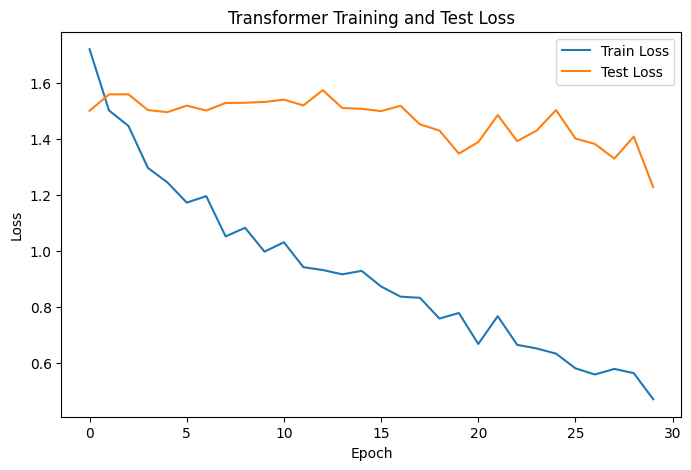

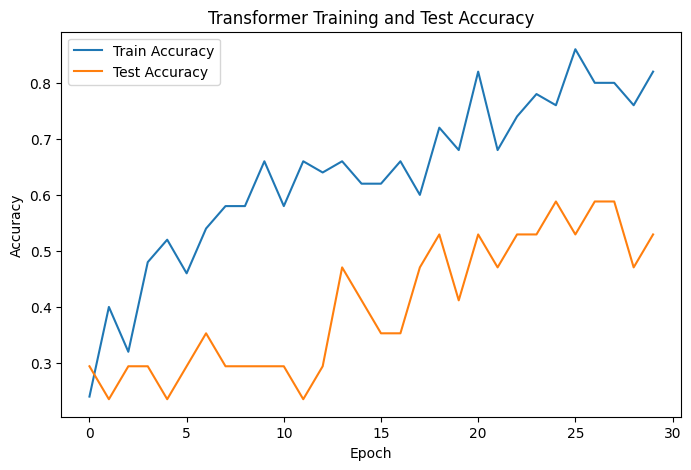

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Test Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], label="Train Accuracy")
plt.plot(history["test_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Training and Test Accuracy")
plt.legend()
plt.show()

## 18. Final evaluation

The model is evaluated using the same metrics as the previous models:

- accuracy
- weighted precision
- weighted recall
- weighted F1-score
- classification report

This makes it easy to compare with Random Forest, HMM, LSTM, and ST-GCN.

In [19]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_targets)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)

print("Accuracy:", round(accuracy, 4))
print("Weighted Precision:", round(precision, 4))
print("Weighted Recall:", round(recall, 4))
print("Weighted F1-score:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
))

Accuracy: 0.5294
Weighted Precision: 0.4608
Weighted Recall: 0.5294
Weighted F1-score: 0.4818

Classification Report:
              precision    recall  f1-score   support

      before       0.33      0.25      0.29         4
    computer       1.00      1.00      1.00         4
        cool       0.00      0.00      0.00         3
      cousin       0.50      0.67      0.57         3
       drink       0.33      0.67      0.44         3

    accuracy                           0.53        17
   macro avg       0.43      0.52      0.46        17
weighted avg       0.46      0.53      0.48        17



## 19. Confusion matrix

The confusion matrix shows which signs were confused.

This is important for understanding model weaknesses at class level.

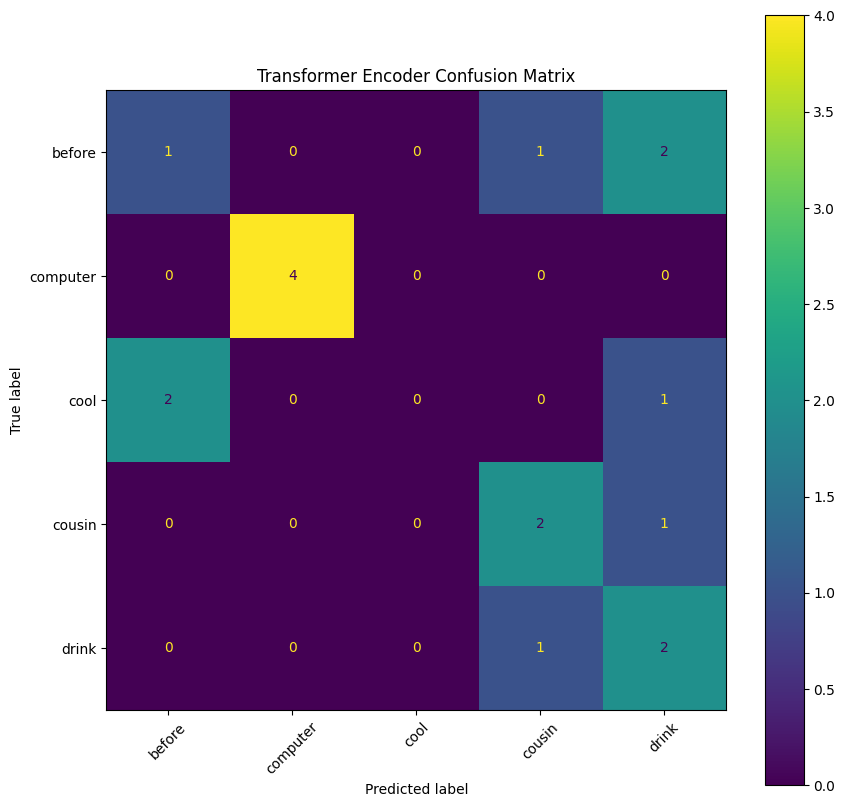

In [20]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Transformer Encoder Confusion Matrix")
plt.show()

## 20. Save model package

This saves:

- Transformer model weights
- label encoder
- scaler
- model metadata

The metadata file can be used later when updating the analytic model comparison report.

In [21]:
transformer_model_path = MODEL_DIR / "transformer_wlasl_landmark_model.pt"
transformer_encoder_path = MODEL_DIR / "transformer_label_encoder.joblib"
transformer_scaler_path = MODEL_DIR / "transformer_scaler.joblib"
transformer_metadata_path = MODEL_DIR / "transformer_metadata.json"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_size": INPUT_SIZE,
        "num_classes": NUM_CLASSES,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dim_feedforward": DIM_FEEDFORWARD,
        "dropout": DROPOUT,
        "classes": list(label_encoder.classes_),
    },
    transformer_model_path,
)

joblib.dump(label_encoder, transformer_encoder_path)
joblib.dump(scaler, transformer_scaler_path)

metadata = {
    "model": "Transformer Encoder landmark baseline",
    "dataset": DATASET_NAME,
    "selected_classes": list(label_encoder.classes_),
    "feature_type": "MediaPipe pose + hand + face landmark sequences",
    "sequence_length": int(MAX_FRAMES),
    "frame_stride": int(FRAME_STRIDE),
    "num_samples": int(len(y_labels)),
    "input_size": int(INPUT_SIZE),
    "d_model": int(D_MODEL),
    "nhead": int(NHEAD),
    "num_layers": int(NUM_LAYERS),
    "accuracy": float(accuracy),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1": float(f1),
}

transformer_metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved Transformer model:", transformer_model_path)
print("Saved label encoder:", transformer_encoder_path)
print("Saved scaler:", transformer_scaler_path)
print("Saved metadata:", transformer_metadata_path)

Saved Transformer model: /workspace/dataset/ksl_project_data/models/transformer_wlasl_landmark_model.pt
Saved label encoder: /workspace/dataset/ksl_project_data/models/transformer_label_encoder.joblib
Saved scaler: /workspace/dataset/ksl_project_data/models/transformer_scaler.joblib
Saved metadata: /workspace/dataset/ksl_project_data/models/transformer_metadata.json
